<a href="https://colab.research.google.com/github/hamed85/Python_Practices/blob/main/PySpark_Part2_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementing Machine Learning Methods Using PySpark**

**Introduction:**

**What is PySpark?**

Apache Spark is an open-source distributed computing framework designed for processing large-scale datasets efficiently. PySpark is the Python API for Spark, allowing data scientists and engineers to build machine learning pipelines using Python.

PySpark MLlib provides scalable implementations of:

- Classification
- Regression
- Clustering
- Recommendation systems
- Feature engineering
- Model evaluation

**Why Use PySpark for Machine Learning?**

Advantages include:

- Handles datasets larger than memory
- Distributed computation
- Built-in machine learning library
- Fault tolerance
- Easy integration with data lakes and cloud platforms

**Agenda:**

In this tutorial you learned how to:

- Load CSV data into PySpark
- Explore and clean data
- Engineer features
- Build classification models: 1) Logistic Regression, 2) Decision Trees, 3) Random Forest
- Build regression models: Linear Regression
- Build clustering models: K-Means
- Create ML pipelines
- Perform hyperparameter tuning

In [ ]:

################################# Create a dataset for employees #################################

import pandas as pd
import numpy as np
import random

'''
np.random.seed(42)
random.seed(42)
n_employees = 1000000
departments = ["IT", "HR", "Finance", "Sales", "Marketing", "Operations"]
education_levels = ["High School", "Bachelor", "Master", "PhD"]
employees = []

for i in range(1, n_employees + 1):
    age = np.random.randint(22, 61)
    years_exp = max(0, min(age - 21, int(np.random.normal((age - 22) * 0.6, 4))))
    department = random.choice(departments)
    education = np.random.choice(education_levels, p=[0.15, 0.45, 0.30, 0.10])
    training_hours = np.random.randint(5, 60)
    overtime_hours = np.random.randint(0, 40)
    remote_work = np.random.choice(["Yes", "No"], p=[0.45, 0.55])

    performance_score = int(np.clip(np.random.normal(75 + years_exp * 0.6, 8), 50, 100))
    edu_bonus = {"High School": 0, "Bachelor": 500, "Master": 1200, "PhD": 2500}
    salary = (3000 + years_exp*250 + edu_bonus[education] + performance_score*20 + np.random.normal(0, 500))

    salary = round(max(3000, salary), 2)
    attrition_score = (overtime_hours * 0.08 - years_exp * 0.05 - performance_score * 0.03)
    attrition_prob = 1 / (1 + np.exp(-attrition_score))
    attrition = ("Yes" if np.random.random() < attrition_prob * 0.7 else "No")

    employees.append([100000 + i, age, np.random.choice(["Male", "Female"]), department,
                      education, years_exp, salary, performance_score, training_hours,overtime_hours, remote_work, attrition])

employees_df = pd.DataFrame(employees, columns=["employee_id", "age", "gender", "department",
                                                "education", "years_experience", "monthly_salary",
                                                "performance_score", "training_hours",    "overtime_hours", "remote_work", "attrition"])
employees_df.to_csv("employees.csv", index=False)
'''

'\nnp.random.seed(42)\nrandom.seed(42)\nn_employees = 1000000\ndepartments = ["IT", "HR", "Finance", "Sales", "Marketing", "Operations"]\neducation_levels = ["High School", "Bachelor", "Master", "PhD"]\nemployees = []\n\nfor i in range(1, n_employees + 1):\n    age = np.random.randint(22, 61)\n    years_exp = max(0, min(age - 21, int(np.random.normal((age - 22) * 0.6, 4))))\n    department = random.choice(departments)\n    education = np.random.choice(education_levels, p=[0.15, 0.45, 0.30, 0.10])\n    training_hours = np.random.randint(5, 60)\n    overtime_hours = np.random.randint(0, 40)\n    remote_work = np.random.choice(["Yes", "No"], p=[0.45, 0.55])\n\n    performance_score = int(np.clip(np.random.normal(75 + years_exp * 0.6, 8), 50, 100))\n    edu_bonus = {"High School": 0, "Bachelor": 500, "Master": 1200, "PhD": 2500}\n    salary = (3000 + years_exp*250 + edu_bonus[education] + performance_score*20 + np.random.normal(0, 500))\n\n    salary = round(max(3000, salary), 2)\n    attr

In [ ]:
################################# Environment setup #################################

import pyspark
print(pyspark.__version__)

# Creating a spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("MachineLearningTutorial").getOrCreate()
print("Spark Session Created")

4.0.2
Spark Session Created


In [ ]:
################################# Loading the csv files #################################

# Loading the employees dataset into a spark DataFrame
employees_df = spark.read.csv("employees.csv", header=True, inferSchema=True)
employees_df.show(10)

+-----------+---+------+----------+---------+----------------+--------------+-----------------+--------------+--------------+-----------+---------+
|employee_id|age|gender|department|education|years_experience|monthly_salary|performance_score|training_hours|overtime_hours|remote_work|attrition|
+-----------+---+------+----------+---------+----------------+--------------+-----------------+--------------+--------------+-----------+---------+
|     100001| 60|Female|Operations|   Master|              20|      10972.69|               91|            25|            38|        Yes|       No|
|     100002| 45|Female|        IT|   Master|              10|        8106.1|               81|            57|             1|         No|       No|
|     100003| 49|  Male|        IT| Bachelor|              17|       9067.44|               79|            56|             2|         No|      Yes|
|     100004| 35|  Male|Operations|   Master|              14|      10186.14|               78|            13|  

In [ ]:
################################# Data exploratory analysis #################################

# View schema
employees_df.printSchema()

# Count records
print(employees_df.count())

# Summary statistics
employees_df.describe().show()

root
 |-- employee_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- department: string (nullable = true)
 |-- education: string (nullable = true)
 |-- years_experience: integer (nullable = true)
 |-- monthly_salary: double (nullable = true)
 |-- performance_score: integer (nullable = true)
 |-- training_hours: integer (nullable = true)
 |-- overtime_hours: integer (nullable = true)
 |-- remote_work: string (nullable = true)
 |-- attrition: string (nullable = true)

1000000
+-------+-----------------+----------------+-------+----------+---------+-----------------+------------------+-----------------+------------------+----------------+-----------+---------+
|summary|      employee_id|             age| gender|department|education| years_experience|    monthly_salary|performance_score|    training_hours|  overtime_hours|remote_work|attrition|
+-------+-----------------+----------------+-------+----------+---------+---------------

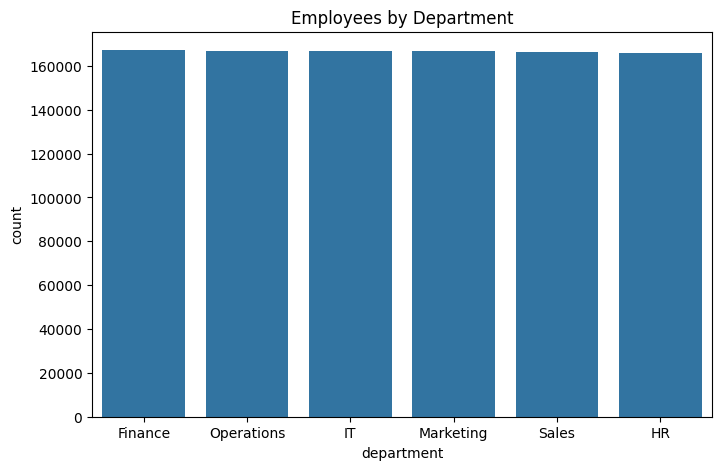

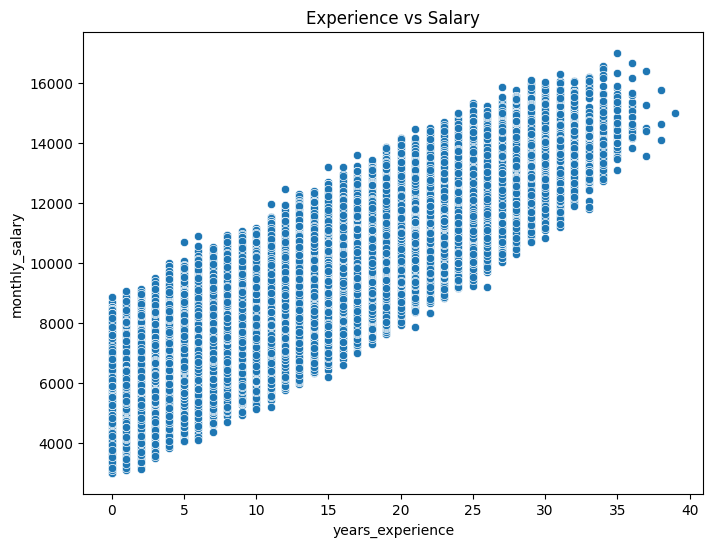

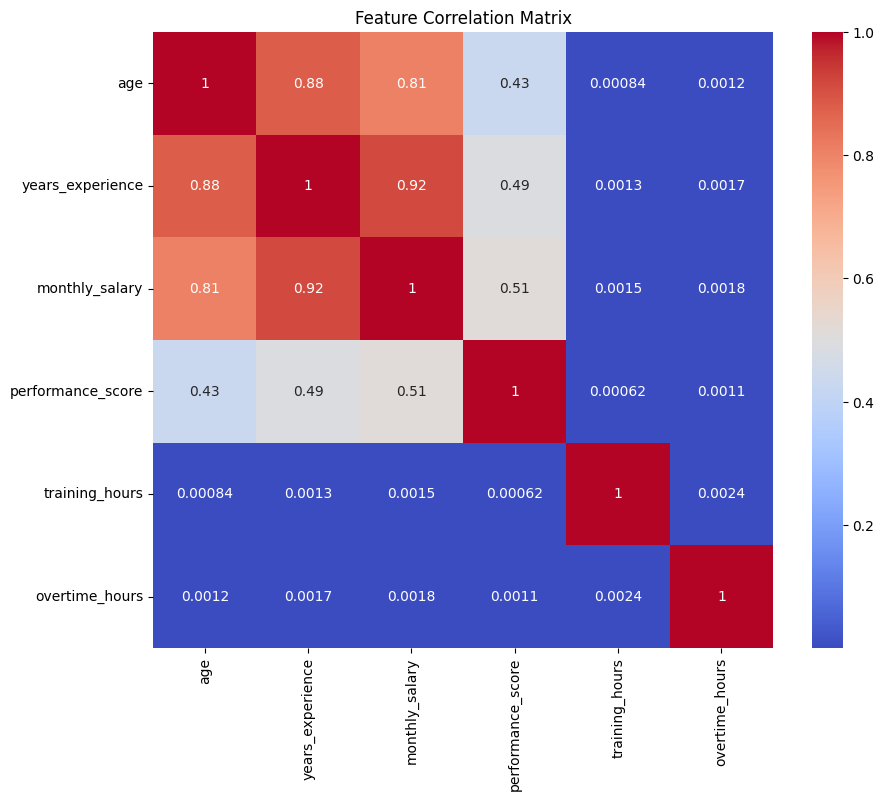

In [ ]:

################################# Create Some Visualizations for Employees Attrition #################################
# Department-wise Employee Count
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas DataFrame
dept_counts = (employees_df.groupBy("department").count().orderBy("count", ascending=False).toPandas())

plt.figure(figsize=(8,5))
sns.barplot(data=dept_counts, x="department", y="count")
plt.title("Employees by Department")
plt.show()

# Experience vs Salary
salary_exp = employees_df.select("years_experience", "monthly_salary").toPandas()
plt.figure(figsize=(8,6))
sns.scatterplot(data=salary_exp, x="years_experience", y="monthly_salary")
plt.title("Experience vs Salary")
plt.show()

# Correlation Heatmap for Feature Engineering
numeric_df = employees_df.select("age", "years_experience", "monthly_salary",
                                 "performance_score", "training_hours",
                                 "overtime_hours").toPandas()
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
################################# Data cleaning #################################
# Remove missing values
employees_df.select([employees_df[c].isNull().alias(c) for c in employees_df.columns]).show()
employees_df = employees_df.na.drop()

# Remove duplicates
employees_df = employees_df.dropDuplicates()

+-----------+-----+------+----------+---------+----------------+--------------+-----------------+--------------+--------------+-----------+---------+
|employee_id|  age|gender|department|education|years_experience|monthly_salary|performance_score|training_hours|overtime_hours|remote_work|attrition|
+-----------+-----+------+----------+---------+----------------+--------------+-----------------+--------------+--------------+-----------+---------+
|      false|false| false|     false|    false|           false|         false|            false|         false|         false|      false|    false|
|      false|false| false|     false|    false|           false|         false|            false|         false|         false|      false|    false|
|      false|false| false|     false|    false|           false|         false|            false|         false|         false|      false|    false|
|      false|false| false|     false|    false|           false|         false|            false|   

**Fix Data Types**

Before you get started modeling, it's important to know that Spark only handles `numeric data`. That means all of the columns in your DataFrame must be either integers or decimals (called 'doubles' in Spark).

When we imported our data, we let Spark guess what kind of information each column held. Unfortunately, Spark doesn't always guess right and you can see that some of the columns in our DataFrame are strings containing numbers as opposed to actual numeric values.

To remedy this, you can use the .cast() method in combination with the .withColumn() method. It's important to note that .cast() works on columns, while .withColumn() works on DataFrames.

The only argument you need to pass to .cast() is the kind of value you want to create, in string form. For example, to create integers, you'll pass the argument "integer" and for decimal numbers you'll use "double".

**Strings and Factors**

As you know, Spark requires numeric data for modeling. So far this hasn't been an issue; even boolean columns can easily be converted to integers without any trouble. But you'll also be using the airline and the plane's destination as features in your model. These are coded as strings and there isn't any obvious way to convert them to a numeric data type.

Fortunately, PySpark has functions for handling this built into the `pyspark.ml.features` submodule. You can create what are called `'one-hot vectors'` to represent the carrier and the destination of each flight. A one-hot vector is a way of representing a categorical feature where every observation has a vector in which all elements are zero except for at most one element, which has a value of one (1).

Each element in the vector corresponds to a level of the feature, so it's possible to tell what the right level is by seeing which element of the vector is equal to one (1).

The first step to encoding your categorical feature is to create a `StringIndexer`. Members of this class are Estimators that take a DataFrame with a column of strings and map each unique string to a number. Then, the Estimator returns a Transformer that takes a DataFrame, attaches the mapping to it as metadata, and returns a new DataFrame with a numeric column corresponding to the string column.

The second step is to encode this numeric column as a one-hot vector using a `OneHotEncoder`. This works exactly the same way as the StringIndexer by creating an Estimator and then a Transformer. The end result is a column that encodes your categorical feature as a vector that's suitable for machine learning routines!

**Carrier**

In this exercise you'll create a` StringIndexer` and a `OneHotEncoder` to code the carrier column. To do this, you'll call the class constructors with the arguments inputCol and outputCol. The `inputCol` is the name of the column you want to index or encode, and the `outputCol` is the name of the new column that the Transformer should create.

In [ ]:
################################# Feature Engineering #################################
# Machine learning models require numerical features
# String Indexing
# Convert categorical columns into numeric values

from pyspark.ml.feature import StringIndexer

gender_indexer = StringIndexer(inputCol="gender", outputCol="gender_index")
model = gender_indexer.fit(employees_df)
employees_df = model.transform(employees_df)

# One-Hot Encoding
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(inputCols=["gender_index"], outputCols=["gender_vector"])
employees_df = encoder.fit(employees_df).transform(employees_df)

# Feature Vector Assembly
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=["age", "years_experience", "performance_score",
                                       "training_hours", "overtime_hours"], outputCol="features")
employees_df = assembler.transform(employees_df)

**Classification Example: Employee Attrition Prediction**

Target variable: attrition

Values: Yes / No

In [ ]:
# Convert Target Variable
# Drop label column if it exists to make the cell re-runnable
if "label" in employees_df.columns:
    employees_df = employees_df.drop("label")

label_indexer = StringIndexer(inputCol="attrition", outputCol="label")
employees_df = label_indexer.fit(employees_df).transform(employees_df)

# Train Test Split Data
train_df, test_df = employees_df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Logistic Regression for the Binary Classification

# Train Model
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)

# Make Predictions
predictions = lr_model.transform(test_df)
predictions.select("prediction", "label").show()

# Evaluate Model
from pyspark.ml.evaluation import (BinaryClassificationEvaluator, MulticlassClassificationEvaluator)

evaluator = BinaryClassificationEvaluator()
auc = evaluator.evaluate(predictions)
print("AUC:", auc)

# Accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = accuracy_evaluator.evaluate(predictions)

# Precision
precision_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",
                                                        metricName="weightedPrecision")
precision = precision_evaluator.evaluate(predictions)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",
                                                     metricName="weightedRecall")
recall = recall_evaluator.evaluate(predictions)

# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
f1 = f1_evaluator.evaluate(predictions)
print(f"AUC       : {auc:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

+----------+-----+
|prediction|label|
+----------+-----+
|       0.0|  1.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  1.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  1.0|
|       0.0|  1.0|
+----------+-----+
only showing top 20 rows
AUC: 0.739686438596087
AUC       : 0.7397
Accuracy  : 0.8317
Precision : 0.7826
Recall    : 0.8317
F1-Score  : 0.7683


In [ ]:
# Decision Tree Classifier
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
dt_model = dt.fit(train_df)
dt_predictions = dt_model.transform(test_df)

In [ ]:
# Random Forest Classification
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

# Evaluate Random Forest
auc = evaluator.evaluate(rf_predictions)
print("Random Forest AUC:", auc)

Random Forest AUC: 0.608659153636599


In [ ]:
# Regression Example: Salary Prediction
# Target: monthly_salary

# Create Feature Vector:
# Drop features column if it exists to make the cell re-runnable
if "features" in employees_df.columns:
    employees_df = employees_df.drop("features")

assembler = VectorAssembler(inputCols=["age", "years_experience", "performance_score",
                                       "training_hours", "overtime_hours"], outputCol="features")
employees_df = assembler.transform(employees_df)

# Split Data
train_df, test_df = employees_df.randomSplit([0.8, 0.2])

# Linear Regression
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="monthly_salary")
model = lr.fit(train_df)
predictions = model.transform(test_df)

# Evaluate RMSE
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="monthly_salary", predictionCol="prediction",
                                metricName="rmse")
rmse = evaluator.evaluate(predictions)
print("RMSE:", rmse)

RMSE: 849.1571057518673


In [ ]:
# Clustering Example
# Employee Segmentation using K-Means.

# Create Features
# Drop features column if it exists to make the cell re-runnable
if "features" in employees_df.columns:
    employees_df = employees_df.drop("features")

assembler = VectorAssembler(inputCols=["age", "years_experience", "monthly_salary",
                                       "performance_score"], outputCol="features")
employees_df = assembler.transform(employees_df)

# Train K-Means
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=4, seed=42)
model = kmeans.fit(employees_df)

# Assign Clusters
clusters = model.transform(employees_df)
clusters.select("employee_id","prediction").show()

+-----------+----------+
|employee_id|prediction|
+-----------+----------+
|     100114|         2|
|     100469|         2|
|     100558|         0|
|     100593|         2|
|     100642|         0|
|     100725|         1|
|     100792|         0|
|     100837|         0|
|     101014|         0|
|     101536|         1|
|     101549|         3|
|     101558|         3|
|     101579|         1|
|     101584|         1|
|     101647|         0|
|     101811|         2|
|     102242|         3|
|     102770|         2|
|     103025|         3|
|     103091|         3|
+-----------+----------+
only showing top 20 rows


**Visualize KMean Cluster Using a 2D Chart**

We want to create a cluster visualization plot, where the data points are projected into 2 dimensions and they are colored by their K-Means cluster assignment. Since the K-Means model is using 4 features:
- age
- years_experience
- monthly_salary
- performance_score
we can't directly visualize all four dimensions on a 2D chart. The standard approach is to use PCA (Principal Component Analysis) to reduce the feature space to two dimensions.

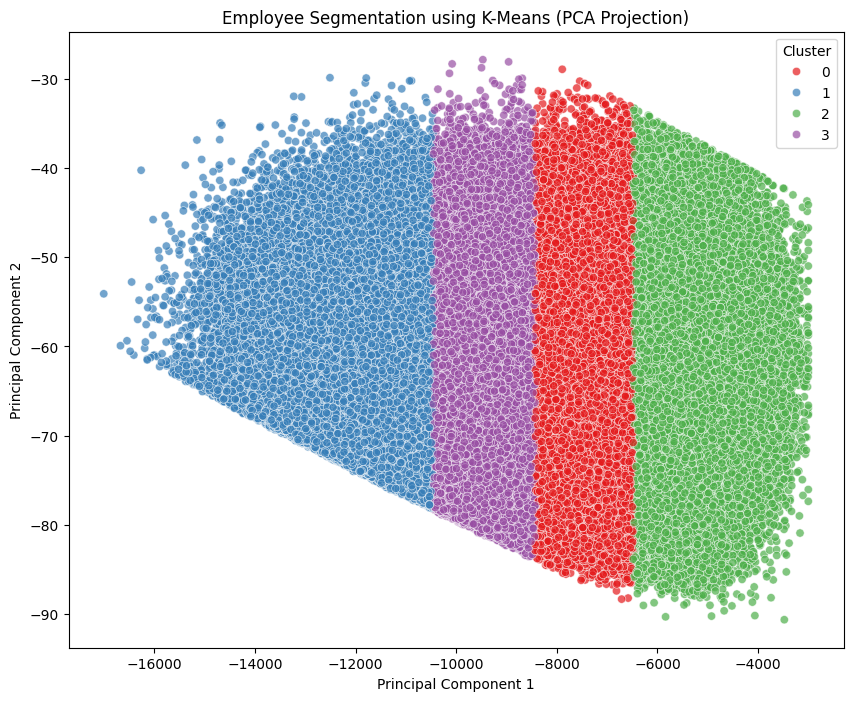

In [ ]:
# Step 1: Apply PCA
from pyspark.ml.feature import PCA

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(employees_df)
pca_df = pca_model.transform(employees_df)

# Step 2: Run K-Means
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=4, featuresCol="features", predictionCol="cluster", seed=42)
model = kmeans.fit(employees_df)
clustered_df = model.transform(employees_df)

# Step 3: Add PCA Coordinates
clustered_df = pca_model.transform(clustered_df)

# Step 4: Extract PCA Components
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

extract_pc1 = udf(lambda v: float(v[0]), DoubleType())
extract_pc2 = udf(lambda v: float(v[1]), DoubleType())
clustered_df = clustered_df.withColumn("PC1", extract_pc1("pca_features")).withColumn("PC2", extract_pc2("pca_features"))

# Step 5: Convert to Pandas
cluster_pd = clustered_df.select("PC1", "PC2", "cluster").toPandas()

# Step 6: Plot the Clusters
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(data=cluster_pd, x="PC1", y="PC2", hue="cluster", palette="Set1", alpha=0.7)
plt.title("Employee Segmentation using K-Means (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

**Machine Learning Pipeline**

PySpark supports end-to-end pipelines. A pipeline is a way to organize the entire machine learning workflow into a sequence of reusable steps. Without pipelines, ML projects become messy, and we lose track of which dataframe contains which transformations.

At the core of the pyspark.ml module are the Transformer and Estimator classes. Almost every other class in the module behaves similarly to these two basic classes. Transformer classes have a .transform() method that takes a DataFrame and returns a new DataFrame; usually the original one with a new column appended. For example, you might use the class Bucketizer to create discrete bins from a continuous feature or the class PCA to reduce the dimensionality of your dataset using principal component analysis.

Estimator classes all implement a .fit() method. These methods also take a DataFrame, but instead of returning another DataFrame they return a model object. This can be something like a StringIndexerModel for including categorical data saved as strings in your models, or a RandomForestModel that uses the random forest algorithm for classification or regression.

A pipeline defines the workflow explicitly:

                 Raw Data
                    ↓
              StringIndexer
                    ↓
              OneHotEncoder
                    ↓
            VectorAssembler
                    ↓
             Random Forest

In [ ]:
# Create a Machine Learning Pipeline

from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier

# Note: Both label and features columns already exist from previous cells
# So the pipeline only needs the classifier
rf = RandomForestClassifier(labelCol="label", featuresCol="features")

pipeline = Pipeline(stages=[rf])
model = pipeline.fit(train_df)
predictions = model.transform(test_df)

In [ ]:
# Hyperparameter Tuning of a Random Forest Model Using Grid Search for the Number of Trees
# Manual parameter testing as a workaround:

from pyspark.ml.classification import RandomForestClassifier

best_auc = 0
best_model = None
best_trees = 0

# Test different values of numTrees
for num_trees in [50, 100, 150]:
    rf_temp = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=num_trees)
    model_temp = rf_temp.fit(train_df)
    predictions_temp = model_temp.transform(test_df)
    auc_temp = evaluator.evaluate(predictions_temp)
    print(f"numTrees={num_trees}, AUC={auc_temp}")

    if auc_temp > best_auc:
        best_auc = auc_temp
        best_model = model_temp
        best_trees = num_trees

print(f"\nBest model: numTrees={best_trees}, AUC={best_auc}")
rf_model = best_model

numTrees=50, AUC=8474.100638349506
numTrees=100, AUC=8474.100638349506
numTrees=150, AUC=8474.100638349506

Best model: numTrees=50, AUC=8474.100638349506


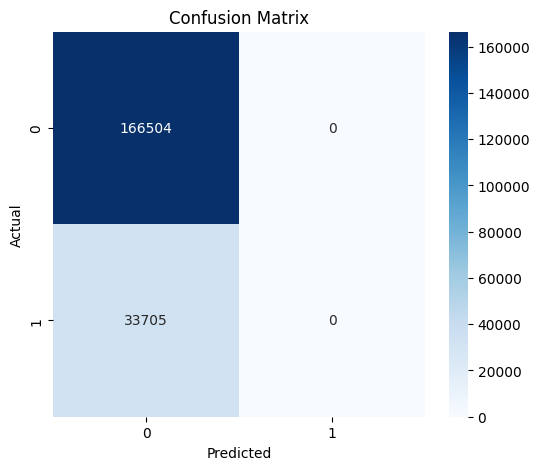

In [ ]:
# Confusion Matrix Visualization After Training the Classifier
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred_pd = predictions.select("label", "prediction").toPandas()
cm = confusion_matrix(pred_pd["label"], pred_pd["prediction"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
